# CZII - CryoET Object Identification

## Import

In [1]:
import zarr
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn import neighbors
import torch
from torch import nn
import torch.nn.functional as functional
import copy
from utilities import plot_3d_points
from matplotlib import cm
from matplotlib.colors import Normalize
import open3d as o3d
from torch.utils.data import Dataset, DataLoader
import json

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### Init dataset zarr files

In [15]:
low_res_dataset = {}
med_res_dataset = {}
hig_res_dataset = {}
for dirname, subdirnames, filenames in os.walk('../data/in/czii-cryo-et-object-identification/train/static/ExperimentRuns/'):
    for subdir in subdirnames:
        if 'zarr' in subdir:
            experiment_run = dirname.split("/")[-2]
            z = zarr.open(os.path.join(dirname, subdir), mode='r')
            hig_res_dataset[experiment_run] = z[0]
            med_res_dataset[experiment_run] = z[1]
            low_res_dataset[experiment_run] = z[2]

In [16]:
particles_locations = {}
for dirname, subdirnames, filenames in os.walk('../data/in/czii-cryo-et-object-identification/train/overlay/ExperimentRuns/'):
    for filename in filenames:
        if dirname.split("/")[-2] not in particles_locations:
            particles_locations[dirname.split("/")[-2]] = {}
        # particle_pos = {}
        with open(os.path.join(dirname, filename)) as f:
            d = json.load(f)
            name = d['pickable_object_name']
            points= []
            for point in d['points']:
                x, y, z = point['location']['x'], point['location']['y'], point['location']['z']
                points.append([x, y, z])
            particles_locations[dirname.split("/")[-2]][d['pickable_object_name']] = points
            # print(particle_pos)
            # particles_locations[dirname.split("/")[-2]] = particle_pos

for experiment in particles_locations:
    print(experiment)
    for particle in particles_locations[experiment]:
        print("\t" + particle, len(particles_locations[experiment][particle]))


TS_6_4
	apo-ferritin 58
	beta-amylase 9
	beta-galactosidase 12
	ribosome 74
	virus-like-particle 10
	thyroglobulin 30
TS_6_6
	apo-ferritin 41
	beta-amylase 14
	beta-galactosidase 11
	ribosome 23
	virus-like-particle 19
	thyroglobulin 35
TS_99_9
	apo-ferritin 36
	beta-amylase 21
	beta-galactosidase 24
	ribosome 65
	virus-like-particle 13
	thyroglobulin 49
TS_5_4
	apo-ferritin 46
	beta-amylase 10
	beta-galactosidase 12
	ribosome 31
	virus-like-particle 11
	thyroglobulin 30
TS_86_3
	apo-ferritin 64
	beta-amylase 9
	beta-galactosidase 23
	ribosome 55
	virus-like-particle 29
	thyroglobulin 45
TS_73_6
	apo-ferritin 95
	beta-amylase 12
	beta-galactosidase 14
	ribosome 46
	virus-like-particle 22
	thyroglobulin 28
TS_69_2
	apo-ferritin 35
	beta-amylase 12
	beta-galactosidase 16
	ribosome 37
	virus-like-particle 9
	thyroglobulin 34


#### Plotting images of tomogram

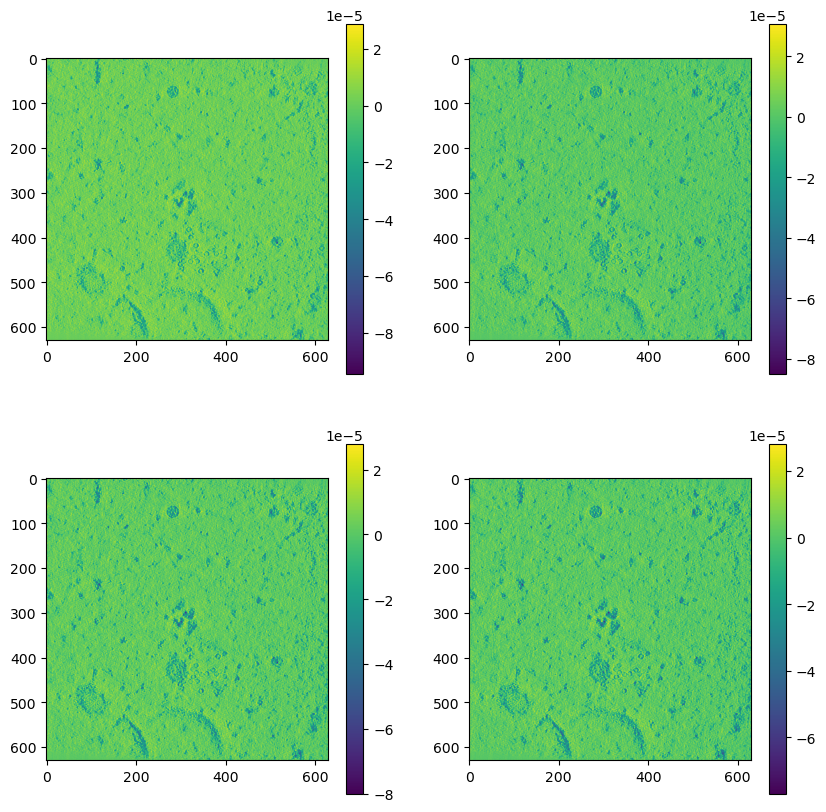

In [19]:
for experiment_run in low_res_dataset:
    z1 = hig_res_dataset[experiment_run]
fig = plt.figure(figsize=(10,10))

start = 60
i = 0
for i in range(z1.shape[0]):
    if i < start:
        continue
    if i > start+3:
        break
    ax = plt.subplot(2, 2, i-start+1)
    _ = plt.imshow(z1[i, :, :])
    plt.colorbar()

#### Plotting 3d representation

In [20]:
scans = np.array(low_res_dataset['TS_5_4'])
norm = Normalize(vmin=scans.min(), vmax=scans.max())

point_cloud = o3d.geometry.PointCloud()
points = []
colors = []
c_values = [np.array(cm.viridis(scans[0][0][0])[:3])]
for experiment_run in range(scans.shape[0]):
    for x in range(scans.shape[1]):
        for y in range(scans.shape[2]):
            points.append(np.array((experiment_run, x, y)))
            color = np.array(cm.viridis(norm(scans[experiment_run][x][y]))[:3])
            colors.append(color)
point_cloud.points = o3d.utility.Vector3dVector(points)
point_cloud.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([point_cloud])

#### Plotting RGB channel for points

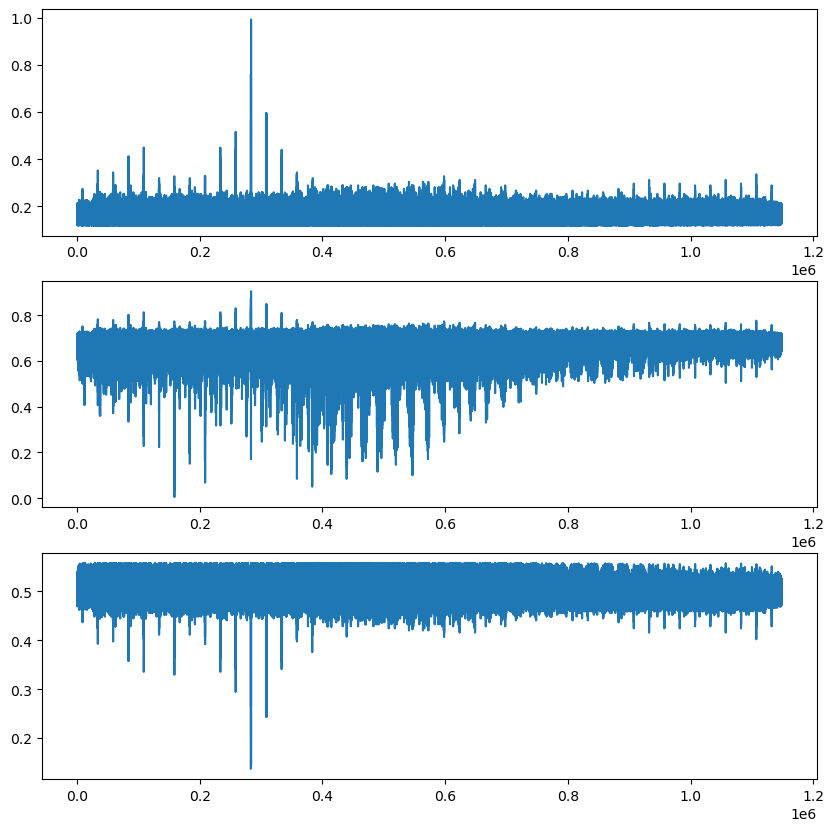

In [21]:
fig = plt.figure(figsize=(10,10))
ax = plt.subplot(3, 1, 1)
ax.plot(np.arange(len(colors)), np.array(colors)[:, 0])
ax = plt.subplot(3, 1, 2)
ax.plot(np.arange(len(colors)), np.array(colors)[:, 1])
ax = plt.subplot(3, 1, 3)
ax.plot(np.arange(len(colors)), np.array(colors)[:, 2])

### Creating dataset

In [ ]:
class CZII_Dataset(Dataset):
    def __init__(self, tomograms, locations):
        self.ys = locations
        self.xs = list(tomograms)

    def __len__(self):
        return len(self.xs)
    
    def __getitem__(self, idx):
        y = self.ys.iloc[idx]
        x = torch.Tensor(np.array(self.xs.iloc[idx]))
        return x, y
